In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding, compute_df_feature, encode_df_feature

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "log_volume", "norm_volume", "time_cos", "time_sin"]
SEQUENCE_SIZE = 60
VOLATILITY_SCALE = 1.
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding(dataset, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

dataset


Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

MifidInstrumentID,delta_event_ts,delta_trading_ts,delta_publication_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts,time_cos,time_sin
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64],list[f64],list[f64]
161,"[0.0, 21.659643, … 0.0]","[0.0, 21.659643, … 0.0]","[0.0, 21.659643, … 0.0]","[0.0, 0.0, … 0.0]","[1.386294, 3.367296, … 0.693147]","[0.000766, 0.000766, … 0.003832]","[0.217788, 1.931375, … -0.360414]","[4, 4, … 4]","[0, 0, … 0]","[4, 3, … 0]","[1, 1, … 0]","[3, 3, … 3]","[1773829826989702, 1773832377713608, … 1773329405626022]","[-0.852205, -0.999639, … 0.932688]","[0.523208, 0.02686, … 0.360683]"
286,"[16.911931, 17.223653, … 0.0]","[16.911931, 17.223653, … 0.0]","[16.911916, 17.223653, … 0.0]","[0.002621, -0.002621, … 0.0]","[5.303305, 5.488938, … 4.369448]","[0.002359, -0.002621, … -0.000257]","[0.733217, 0.968098, … 1.55211]","[7, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773907245799387, 1773907276008454, … 1773333309481413]","[0.085503, 0.079321, … -0.992339]","[0.996338, 0.996849, … 0.123549]"
408,"[18.523729, 15.919555, … 0.0]","[18.523729, 15.919555, … 0.0]","[18.523729, 15.919554, … 0.0]","[-0.002946, -0.014859, … 0.0]","[6.979145, 7.824446, … 6.214608]","[-0.002651, -0.013079, … 0.003175]","[2.425523, 3.158206, … -0.075142]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[1, 1, … 0]","[1, 1, … 1]","[1773908662122017, 1773908670321280, … 1773330609337900]","[-0.203491, -0.205139, … -0.778465]","[0.979077, 0.978733, … 0.627689]"
15,"[19.912846, 18.79567, … 0.0]","[19.912846, 18.79567, … 0.0]","[19.912846, 18.79567, … 0.0]","[0.012739, -0.014572, … 0.0]","[7.601402, 8.517393, … 0.693147]","[0.011282, -0.014572, … 0.0]","[1.27592, 1.801684, … -5.090947]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773910860029954, 1773911005527464, … 1773333319555918]","[-0.609064, -0.632484, … -0.992392]","[0.793121, 0.774574, … 0.123115]"
536,"[0.0, 0.0, … 16.693351]","[0.0, 0.0, … 16.693351]","[0.0, 0.693147, … 16.693329]","[0.0, 0.0, … 0.0]","[5.087596, 4.532599, … 3.091042]","[0.0, 0.0, … 0.0]","[0.533785, -0.244213, … -2.2625]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 3]","[1, 1, … 0]","[2, 2, … 2]","[1773907209585331, 1773907209585331, … 1773333332702418]","[0.091654, 0.091654, … -0.993065]","[0.995791, 0.995791, … 0.117564]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
393,"[0.0, 0.0, … 14.424789]","[0.0, 0.0, … 14.424789]","[0.0, 0.0, … 14.42479]","[0.0, 0.0, … 0.0]","[0.693147, 1.791759, … 3.89182]","[0.0, 0.0, … 0.0]","[-1.307149, -0.065825, … -1.350255]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 3]","[0, 0, … 0]","[1, 1, … 1]","[1773907226727483, 1773907226727483, … 1773333307771943]","[0.08783, 0.08783, … -0.99249]","[0.996136, 0.996136, … 0.122328]"
119,"[22.726157, 21.794997, … 23.311932]","[22.726157, 21.794997, … 23.311932]","[22.726157, 21.794997, … 23.311932]","[0.0, 0.0, … 0.057158]","[6.122493, 7.632401, … 8.006701]","[0.003876, 0.0, … 0.057158]","[-0.428729, 0.848269, … 2.248655]","[4, 4, … 7]","[0, 0, … 0]","[1, 1, … 1]","[0, 1, … 0]","[2, 2, … 2]","[1773837199501000, 1773840119930477, … 1773315717756300]","[-0.486595, 0.091345, … -0.697119]","[-0.873628, -0.995819, … -0.716955]"
244,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.693147, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[5.934894, 3.044522, … 0.693147]","[0.001212, 0.001212, … 0.0]","[-0.034906, -2.608269, … -3.625795]","[4, 4, … 4]","[0, 0, … 0]","[0, 0, … 0]","[0, 0, … 1]","[3, 3, … 3]","[1773675027700700, 1773675027700700, … 1773243013976905]","[-0.602527, -0.602527, … 0.095208]","[0.798098, 0.798098, … 0.995457]"


====== Volatility Model ===== (Task B)

In [2]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



100%|██████████| 598/598 [01:11<00:00,  8.36it/s]


Target mean -->  0.90912896 +/- 2.4164057
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  29.38499689102173
MLX test buffer init in  19.03362202644348
EPOCH 1 --- 


4350it [1:05:16,  1.11it/s]
1865it [04:45,  6.54it/s]


TRAIN LOSS 2.1326349565791016 ||| TEST LOSS 1.4861629248048964
EPOCH 2 --- 


4350it [1:03:22,  1.14it/s]
1865it [05:40,  5.48it/s]


...

TRAIN LOSS 2.1327298425257806 ||| TEST LOSS 1.479953398205958
EPOCH 7 --- 


4350it [1:01:52,  1.17it/s]
1865it [05:03,  6.14it/s]


TRAIN LOSS 2.1337883730702 ||| TEST LOSS 1.481615029864275
EPOCH 8 --- 


3539it [51:43,  1.14it/s]


KeyboardInterrupt: 

======= Variational version ===========

In [ ]:

from src.trainer import VolatilityTrainer
from src.volatility_nn import VariationalVolatilityPredictor
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VariationalVolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



100%|██████████| 598/598 [01:25<00:00,  7.00it/s]


Target mean -->  0.9091287 +/- 2.4164083
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 63628/63628 [01:20<00:00, 795.12it/s]


res (15804,) (15789,)
res (1503,) (1488,)
res (90,) (75,)
res (187,) (172,)
res (6069,) (6054,)
res (622,) (607,)
res (279,) (264,)
res (311,) (296,)
res (193,) (178,)
res (315,) (300,)
res (105,) (90,)
res (2508,) (2493,)
res (88,) (73,)
res (21686,) (21671,)
res (993,) (978,)
res (957,) (942,)
res (219,) (204,)
res (2980,) (2965,)
res (1276,) (1261,)
res (6733,) (6718,)
res (710,) (695,)
6 <_top k
View of topk -> shape: (6, 2)
┌─────────┬───────────┐
│ isin_id ┆ score     │
│ ---     ┆ ---       │
│ i64     ┆ f64       │
╞═════════╪═══════════╡
│ 122     ┆ 0.884676  │
│ 98      ┆ 0.563319  │
│ 497     ┆ -0.229746 │
│ 491     ┆ -0.716374 │
│ 226     ┆ -0.783404 │
│ 125     ┆ -0.797837 │
└─────────┴───────────┘
res (710,) (695,)


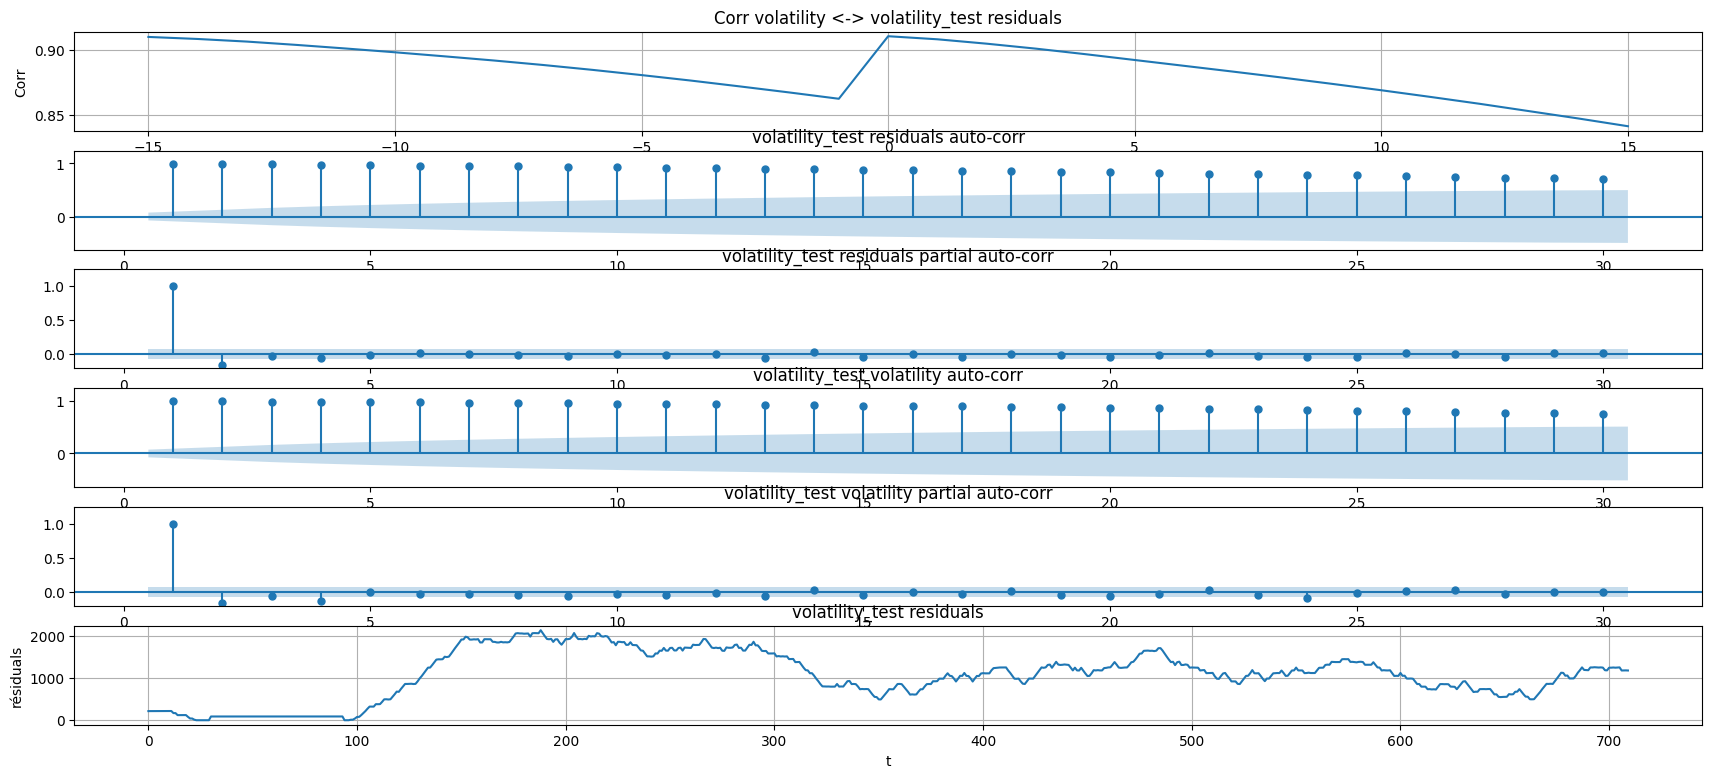

res (1276,) (1261,)


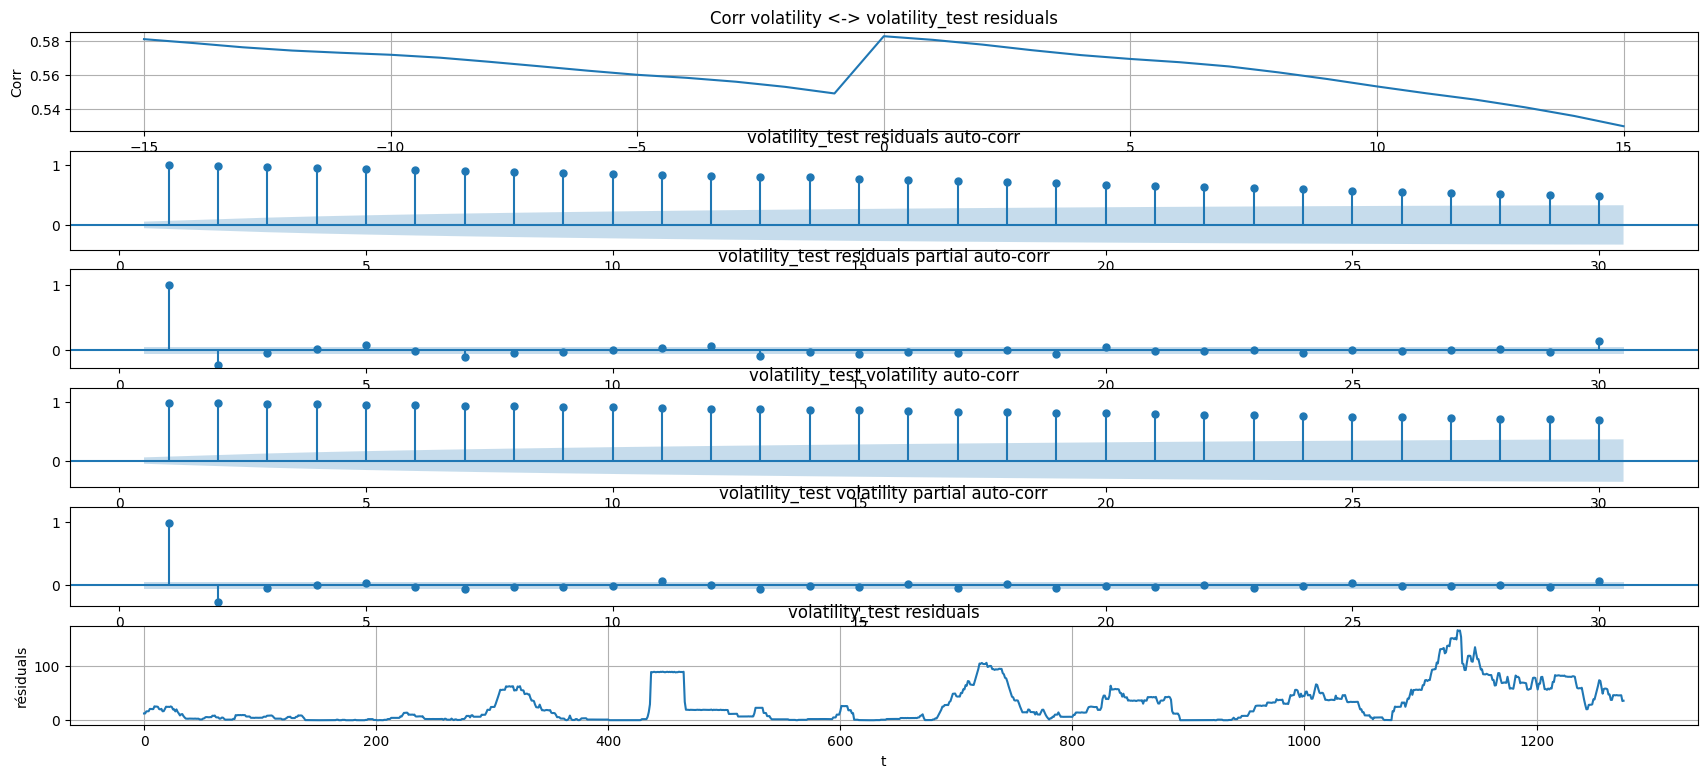

res (90,) (75,)


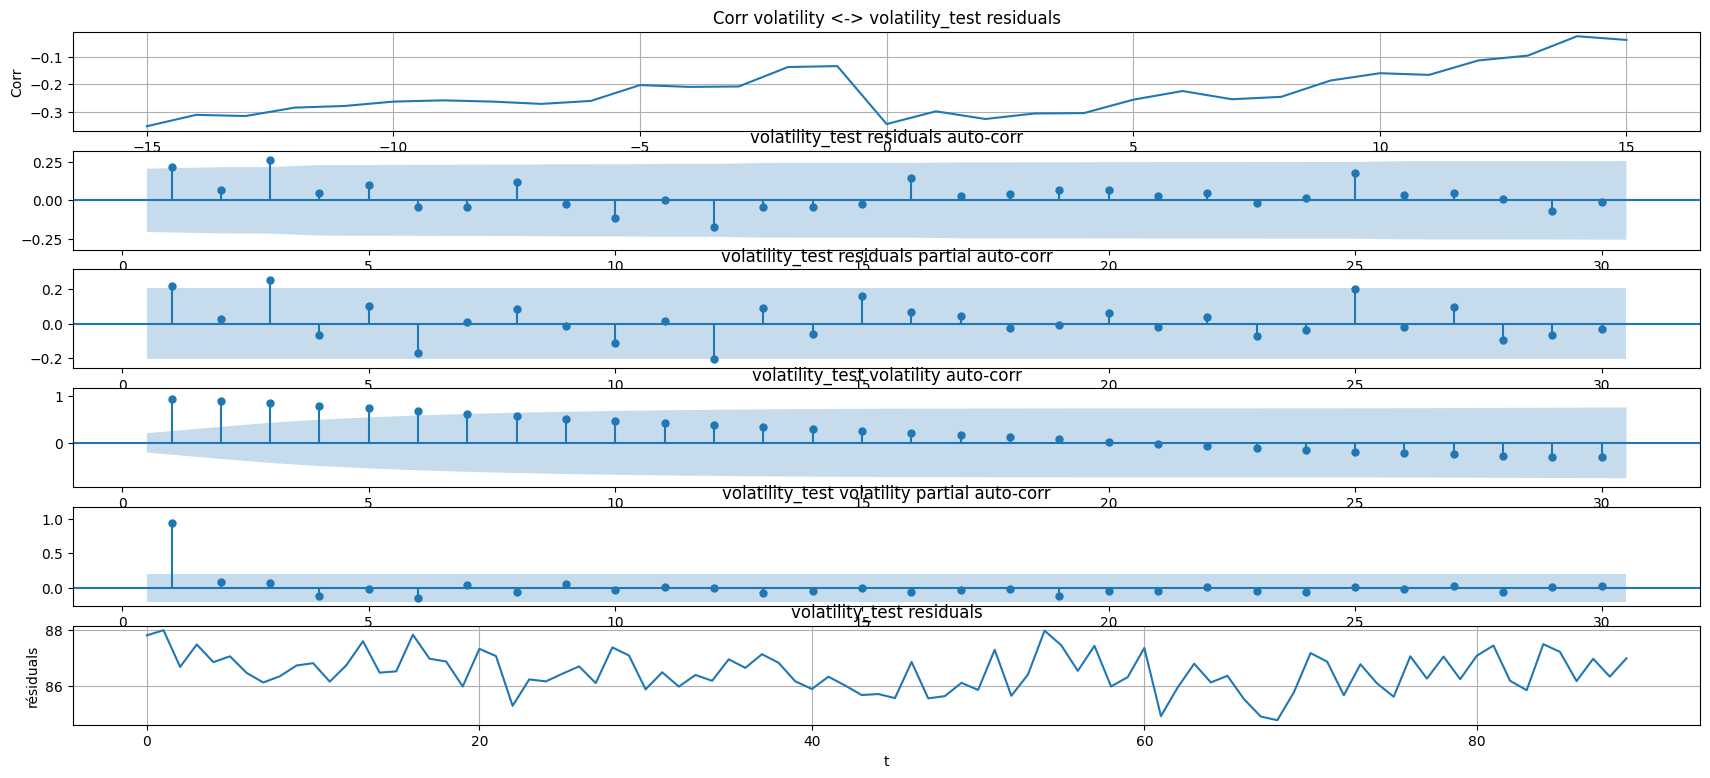

res (105,) (90,)


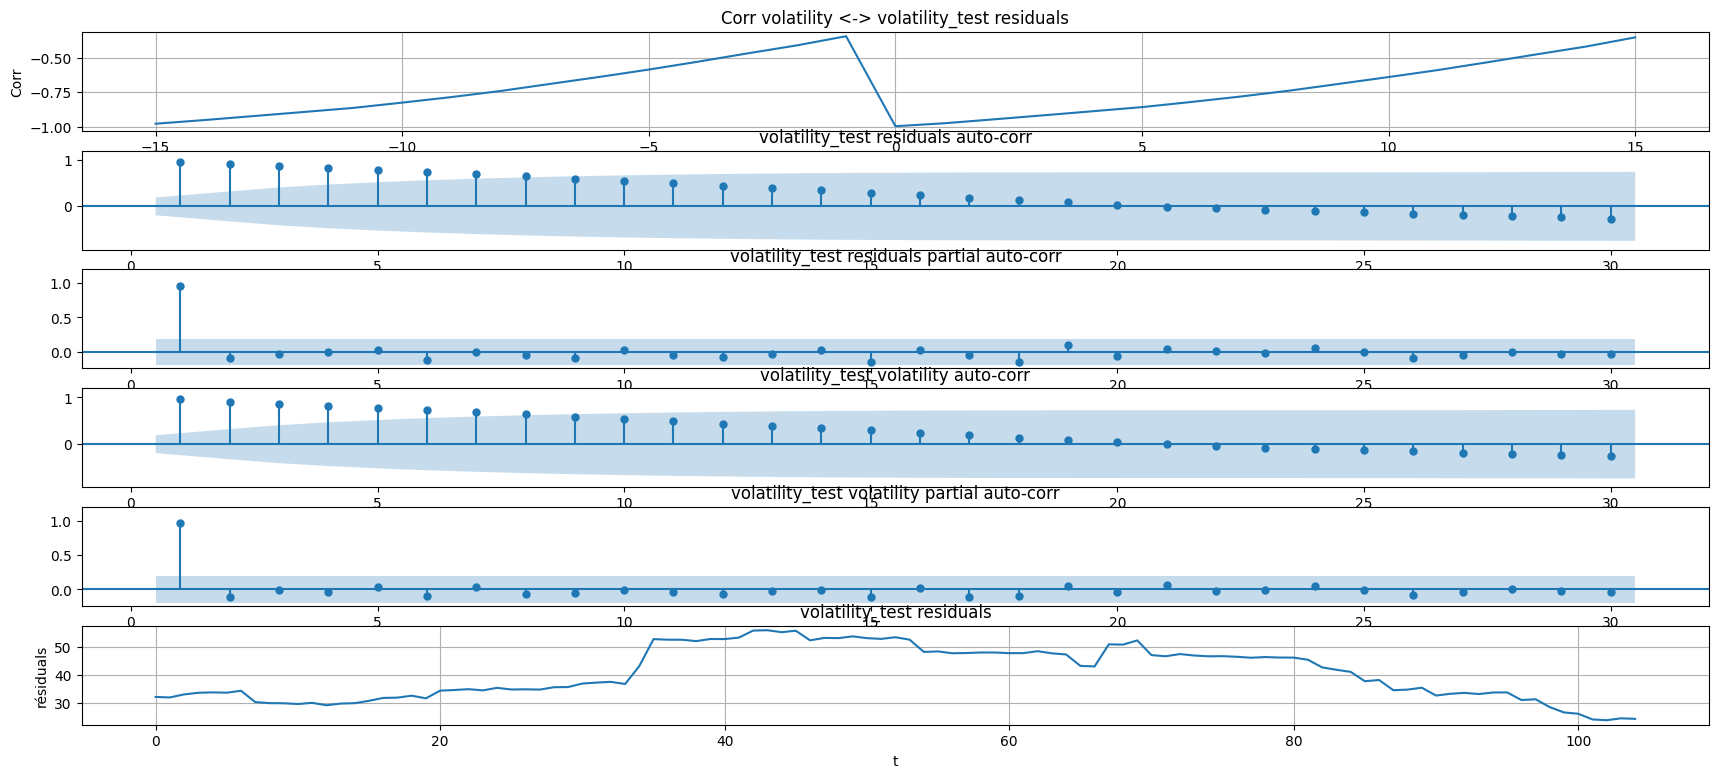

res (219,) (204,)


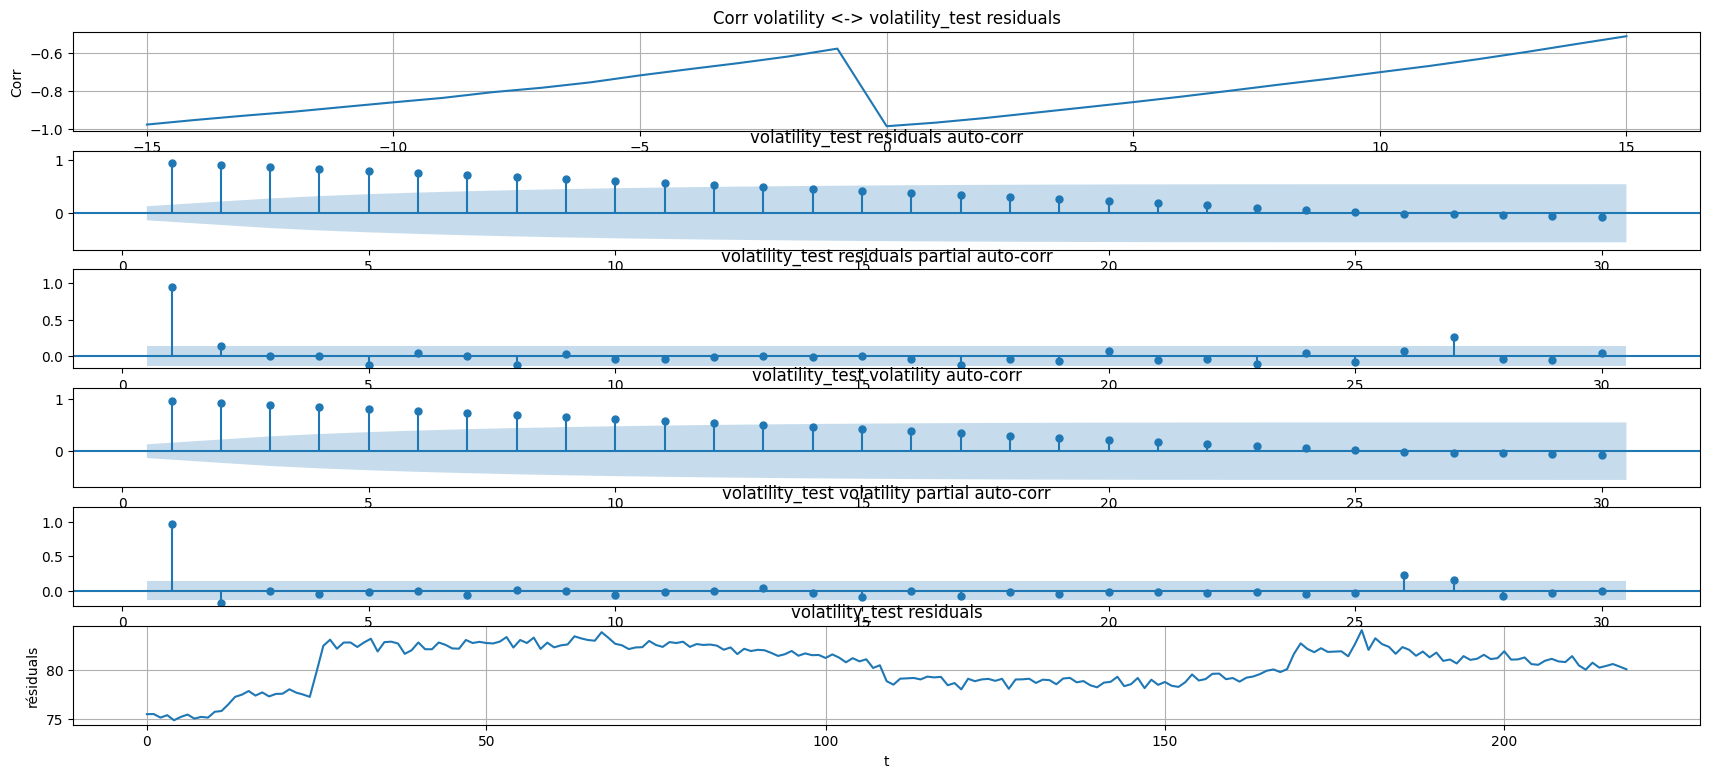

res (193,) (178,)


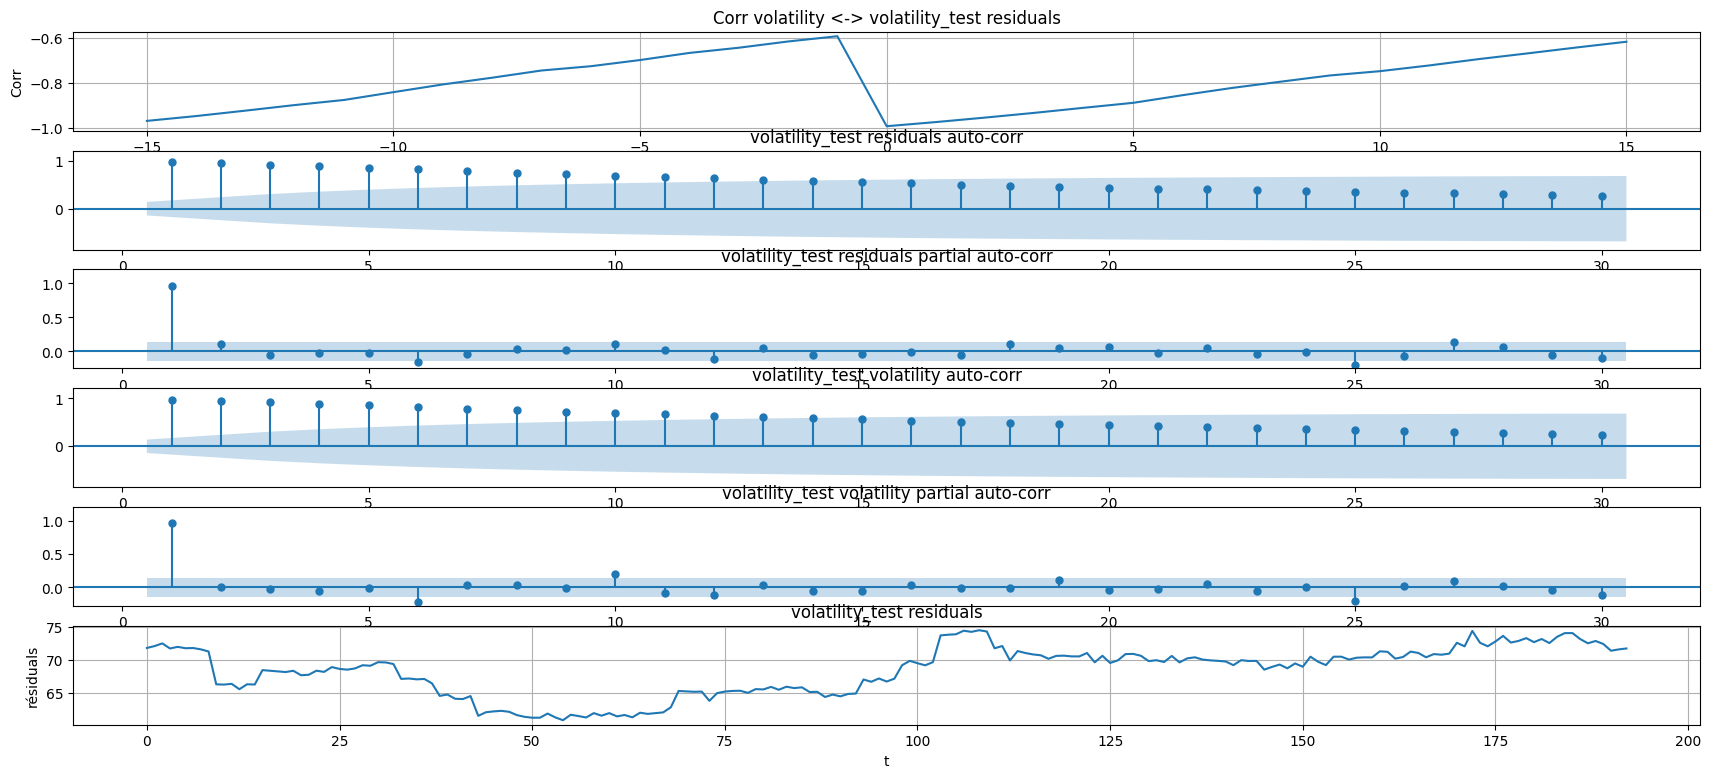

In [2]:
from src.analysis import analyse_volatility_residuals
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

TRAIN_SIZE=0.99

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
volatility_model.load_weights("weight/volatility_model.safetensors")
mx.eval(volatility_model.parameters())

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)

train_lenght = int(len(buffer)*TRAIN_SIZE)
#buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

#volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_volatility_residuals(model=volatility_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS, save_fig = True, name="volatility_test")
#analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")


In [ ]:
import importlib
import src.analysis
importlib.reload(src.analysis)
from src.analysis import plot_hook_path, get_volatility_model_activation, get_hook_similiarity
import seaborn as sns
import pandas as pd

tree_activation = get_volatility_model_activation(model=volatility_model,
                                                  buffer=buffer_test,
                                                  categorical_col=CATEGORIAL_COLUMNS,
                                                  scale= VOLATILITY_SCALE,
                                                  max_isin=10) # We test only on ten asset 
                                                               # @todo find a way to reduce memory print & augment asset's number
                                                            

score, avg_score = get_hook_similiarity(tree=tree_activation, top_layer=0.3)
print("avg score->", avg_score)
print("score->", score)

score_df = pd.DataFrame(score, columns=list(tree_activation.keys()), index=list(tree_activation.keys()))
sns.heatmap(score_df, annot=True)



===========VAE MODEL===========

100%|██████████| 598/598 [00:23<00:00, 25.59it/s]


MLX buffer init in  53.60853672027588 second
MLX train buffer init in  19.403954029083252
MLX test buffer init in  13.629441976547241
EPOCH 1 --- 


4350it [1:00:45,  1.19it/s]
1865it [04:38,  6.69it/s]


TRAIN LOSS -179.24012983344068 ||| TEST LOSS -140.02705514207284
EPOCH 2 --- 


4350it [59:38,  1.22it/s]
1865it [04:55,  6.30it/s]


...

TRAIN LOSS -182.20956762204224 ||| TEST LOSS -140.2509030584995
EPOCH 9 --- 


4350it [58:23,  1.24it/s]
1865it [04:24,  7.05it/s]


TRAIN LOSS -182.2143563246453 ||| TEST LOSS -140.25795375629662
EPOCH 10 --- 


4350it [57:29,  1.26it/s]
1865it [04:21,  7.12it/s]


TRAIN LOSS -182.21673365099676 ||| TEST LOSS -140.24407364996125


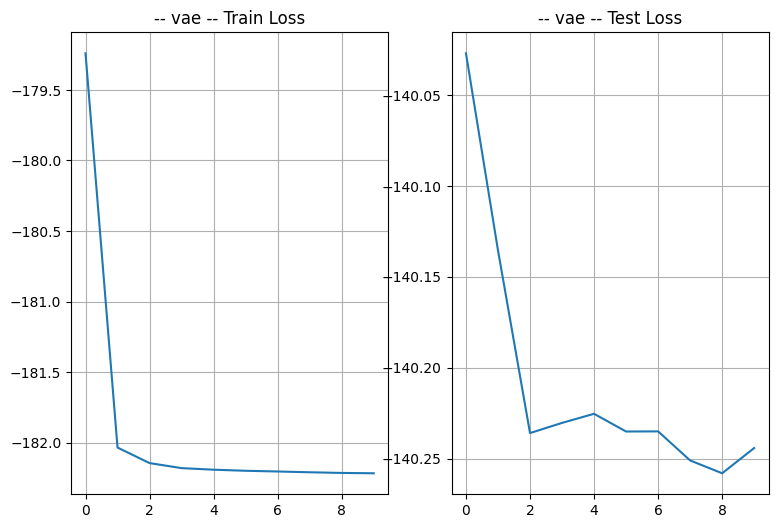

: 

In [ ]:
#import importlib
#import src.vae
#importlib.reload(src.vae)
import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")
vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORIAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae",
                  plot_chart=True)


100%|██████████| 598/598 [01:22<00:00,  7.28it/s]


Target mean -->  0.9091285 +/- 2.4164064
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 31814/31814 [01:10<00:00, 450.80it/s]
/Users/arseneducrocq/miniconda3/envs/ls_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/arseneducrocq/miniconda3/envs/ls_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


4 <_top k
View of topk -> shape: (4, 2)
┌─────────┬───────────┐
│ isin_id ┆ score     │
│ ---     ┆ ---       │
│ i64     ┆ f64       │
╞═════════╪═══════════╡
│ 262     ┆ NaN       │
│ 497     ┆ 0.152129  │
│ 515     ┆ -0.153415 │
│ 357     ┆ -0.316932 │
└─────────┴───────────┘


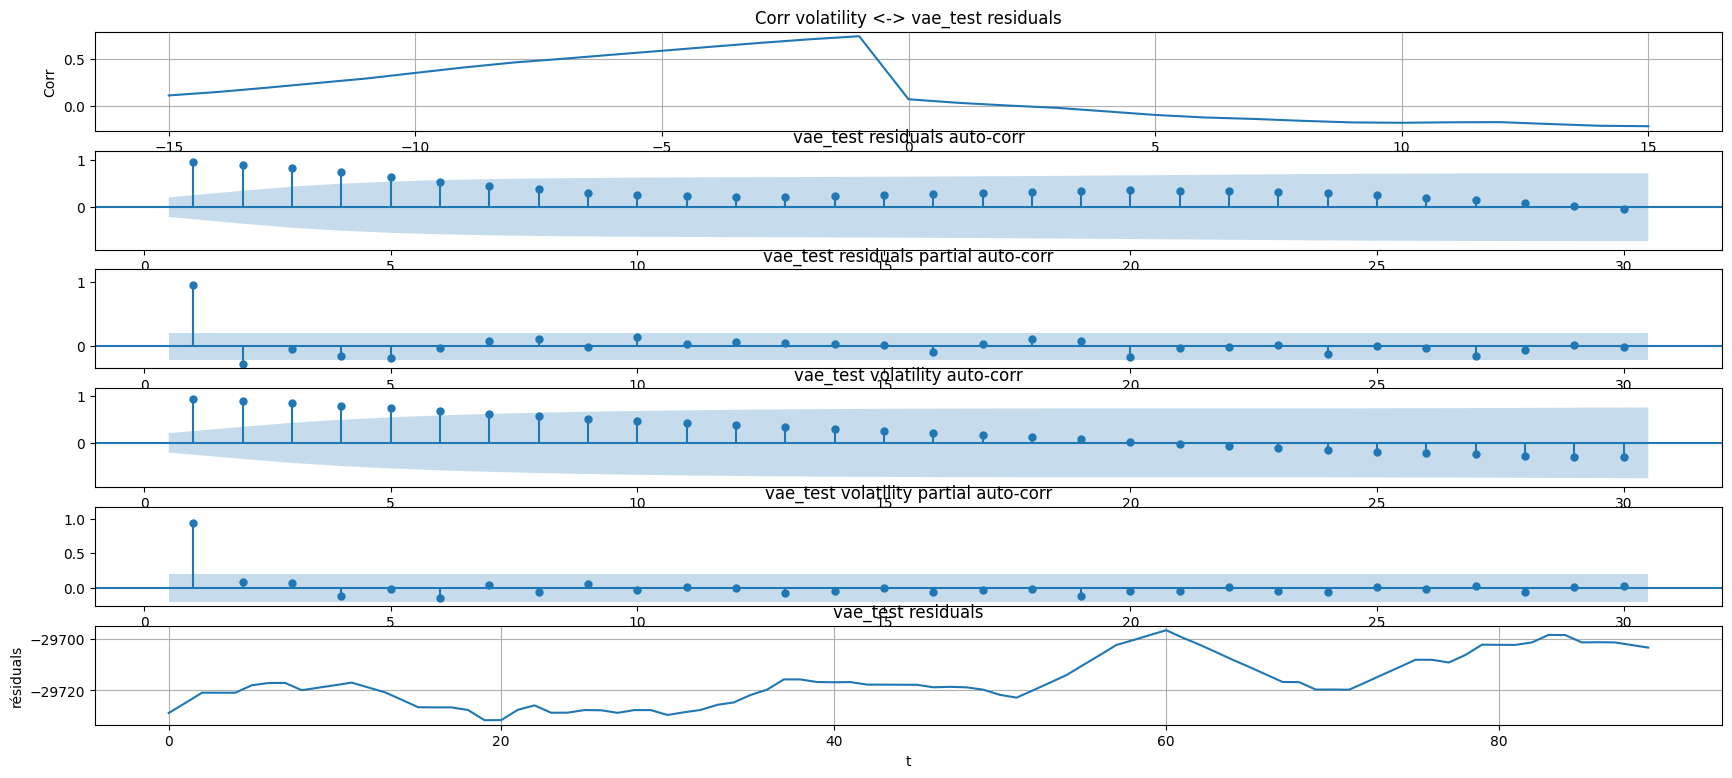

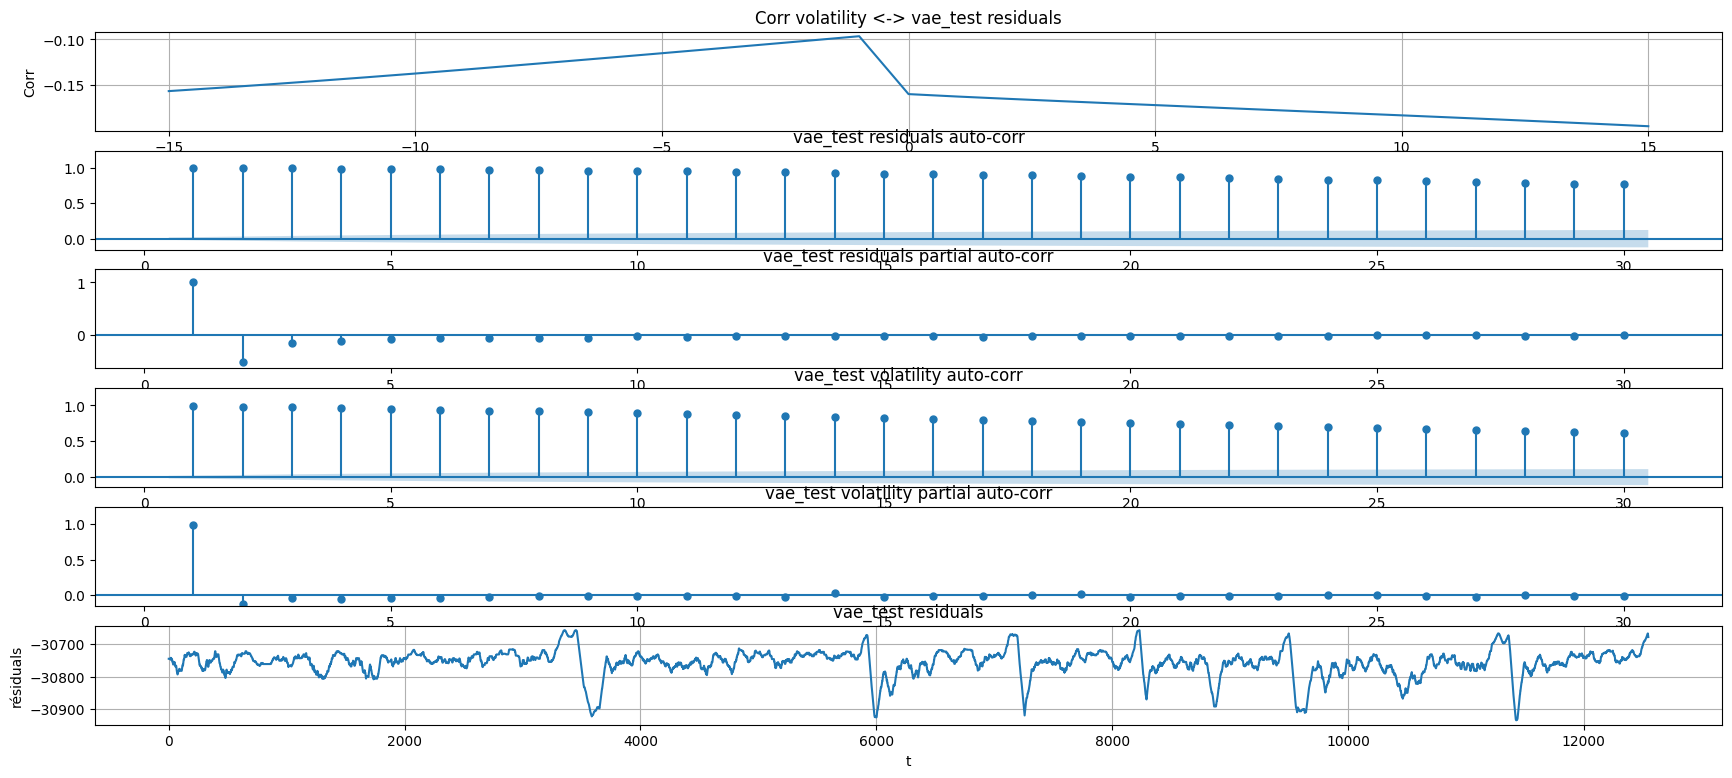

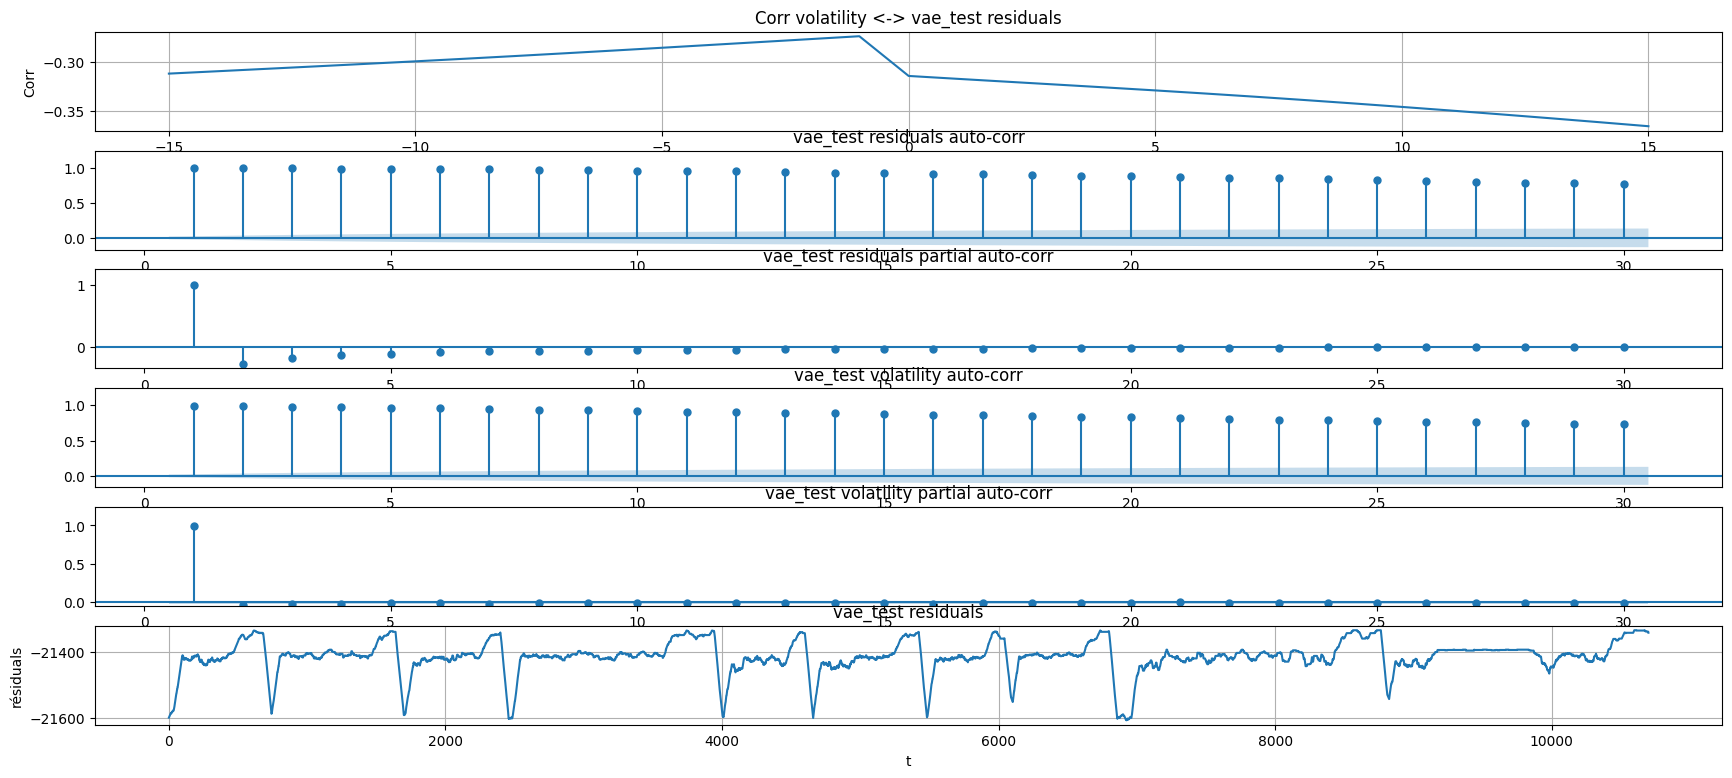

NameError: name 'volatility_sequence_train' is not defined

In [2]:
from src.analysis import analyse_vae_residuals
from src.vae import VAE
from src.config import VAEConfig
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())
TRAIN_SIZE=0.995

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])


#volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_vae_residuals(model=vae_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_test")
analyse_vae_residuals(model=vae_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_train")


==== Prediction Head without encoder pretrained ====

In [ ]:
import src.processing
import src.trainer
import importlib
importlib.reload(src.processing)
importlib.reload(src.trainer)
from src.config import DiscreteConfig
from src.volatility_predictor_nn import DiscreteHead
from src.trainer import DiscretizedVolTrainer
from src.processing import get_volatility_discretize_seq

directional_config = DiscreteConfig(
    num_states=3,
    hidden_size = 32,
    activation = ReLU,
    dropout_rate=0.2
)

directional_model = DiscreteHead(encoder_config=encoder_config, dir_config=directional_config)
mx.eval(directional_model.parameters())
directional_optim_config = OptimizerConfig(optimizer_name="adamw", lr=1e-4)

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )
directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="no_pretrain_discrete_model", plot_chart=True)


100%|██████████| 598/598 [02:31<00:00,  3.95it/s]


MLX train buffer init in  29.788903951644897
MLX test buffer init in  19.21560311317444
EPOCH 1 --- 


7it [00:09,  1.38s/it]


KeyboardInterrupt: 

: 

==== Prediction Head with VAE encoder ======

In [ ]:
VAE_WEIGHT = "weight/vae.safetensors"
directional_model_vae = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config,
                                    encoder_weight=VAE_WEIGHT)
directional_model_vae.encoder.freeze()

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="vae_pretrain_discrete_model", plot_chart=True)


(1000,)

In [ ]:
VOL_WEIGHT = "weight/volatility_model.safetensors"
directional_model_volatility = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config,
                                    encoder_weight=VOL_WEIGHT)
directional_model_volatility.encoder.freeze()

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, 
                          save_dir=SAVE_DIR, 
                          model_name="volatility_pretrain_discrete_model", 
                          plot_chart=True)


===========Clustering & neural net core analyse=============

shape: (9, 1)
┌───────────┐
│ TradeType │
│ ---       │
│ i32       │
╞═══════════╡
│ 6         │
│ null      │
│ 3         │
│ 0         │
│ 4         │
│ 1         │
│ 7         │
│ 2         │
│ 5         │
└───────────┘
(9, 1)
Best k-mean --> {'score': 0.5309972763061523, 'cluster': 2, 'model': KMeans(n_clusters=2, random_state=22)}
Nb dbs cluster--> 3
{np.int64(0): ['41', '25', '1', '33', '20'], np.int64(1): ['39', '39', '40'], np.int64(2): ['105']}


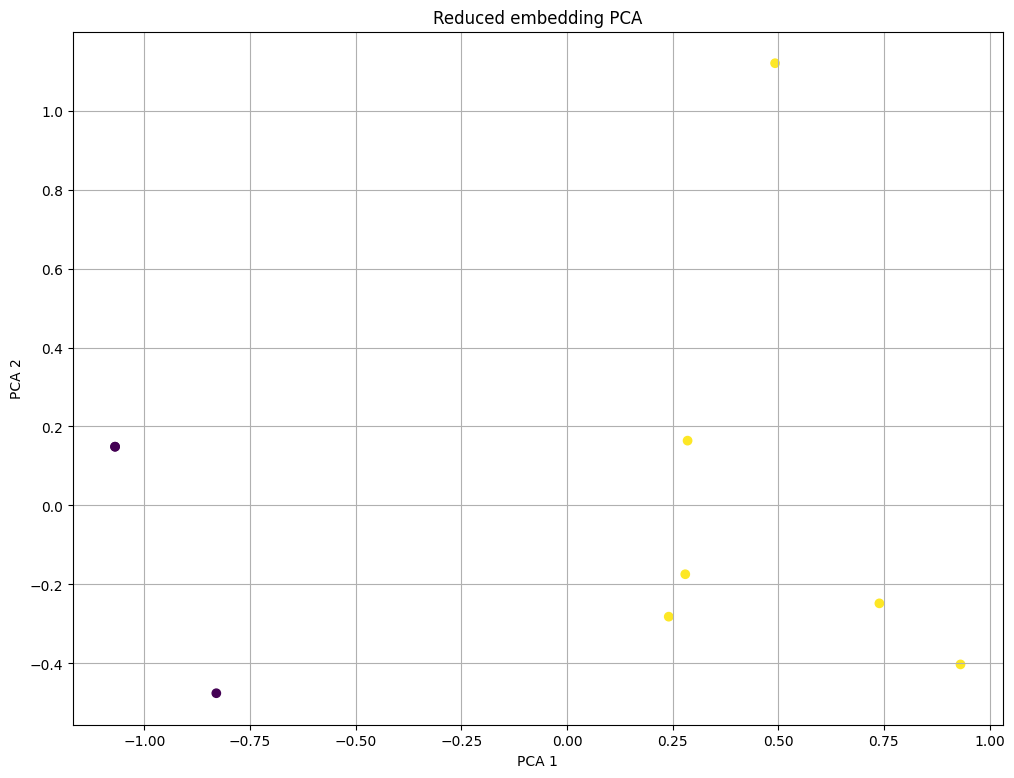

/Users/arseneducrocq/miniconda3/envs/py_env/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


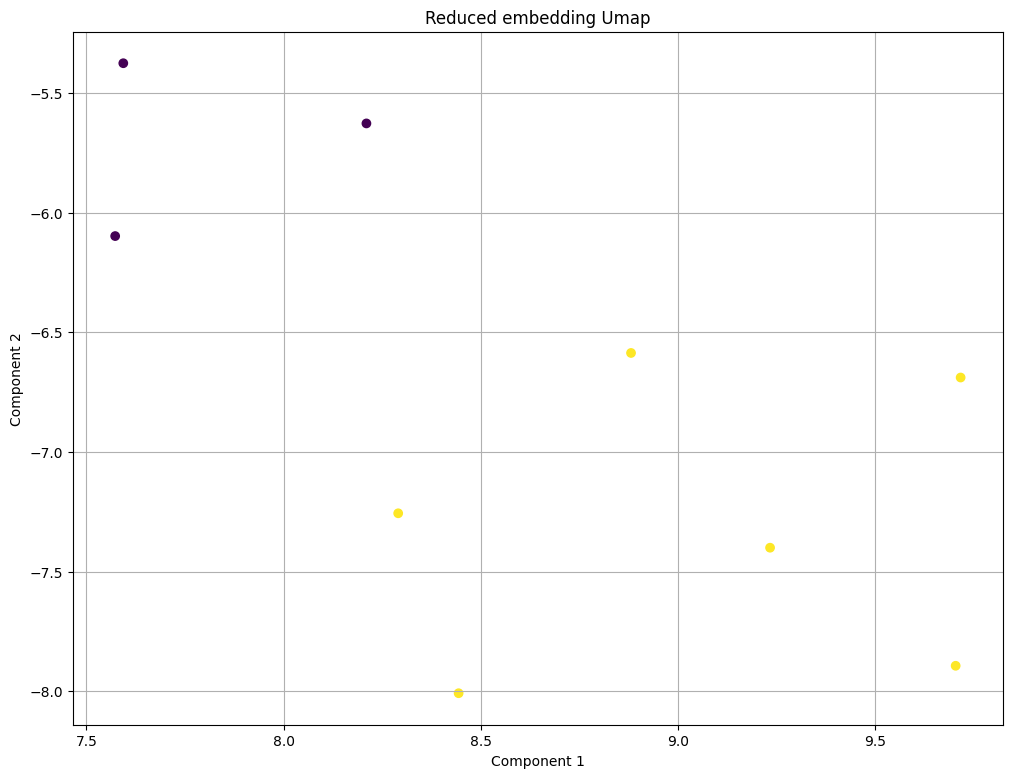

{np.int32(0): ['39', '39', '40'],
 np.int32(1): ['41', '25', '1', '33', '20', '105']}

In [53]:
import src.clustering
import importlib
importlib.reload(src.clustering)
from src.clustering import plot_pca_cluster, plot_umap, get_best_cluster, get_dbscan_cluster, get_group, get_cluster_intersection
import polars as pl
import numpy as np
from src.vae import VAE
from src.config import VAEConfig

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())

# VAE
vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())

def run_analyse(df: pl.DataFrame, col, model, tokenizer):
    data = df.explode(pl.all().exclude(pl.Int32)).select(col).unique()
    print(data)
    subtokenizer = tokenizer[col]
    data = data.to_numpy()
    data = mx.array(data, dtype=mx.int32)
    print(data.shape)
    model_inpt = {col: data}
    pred = model.feature_encoder.categorical_encoder({col: data})[col]
    mx.eval(pred)
    if len(pred.shape) > 2:
        pred = pred[:,0,:]
    pred = np.array(pred)
    best_km = get_best_cluster(embedding=pred, max_cluster=min(100, np.max(data.shape) - 1))

    print("Best k-mean -->", best_km)
    km_pred = best_km["model"].predict(pred)
    data_np = np.array(data[:, 0])
    cluster = get_group(cluster_pred=km_pred, pred_labels=data_np, sub_tokenizer=subtokenizer)

    best_dbs = get_dbscan_cluster(embedding=pred)
    dbs_pred = best_dbs["pred"]
    dbs_cluster = get_group(cluster_pred=dbs_pred, pred_labels=data_np, sub_tokenizer=subtokenizer)
    print("Nb dbs cluster-->", len(dbs_cluster.keys()))
    print(dbs_cluster)
    plot_pca_cluster(embedding=pred, cluster=km_pred, save_fig=False)
    plot_umap(embedding=pred, cluster=km_pred, save_fig=False)
    return cluster

cluster = run_analyse(df=dataset, col="TradeType", model=vae_model, tokenizer=tokenizer)
cluster


In [ ]:
# Volatility

['TradeType',
 'MifidInstrumentID',
 'MmtMarketMechanism',
 'MmtTradingMode',
 'MmtAlgorithmicIndicator',
 'Venue']